# Two Steps MultiFidelity Neural Network

!! ATTENTION !!
In this case, MF ~ HF

In [21]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf


In [22]:
# reproducibility
seed=42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [23]:
# import of the discretization

file_path_D = os.path.join("..", "..", "Diffusion\DATA", "Discretizations_time.txt")

Discretizations= np.loadtxt(
    file_path_D
).astype(
    int
)


In [24]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)


In [25]:
########################     NORMALIZATION  #########################
# Input
reaction_HF_test=normalization(reaction_HF_test)

In [26]:
#########################     TRAIN SET      ##########################
NepoLF = 8000  # number of epochs for first NN: NN_LF
NepoHF = 50  # number of epochs for second NN: NN_HF

Nlf = 100
n_HF = 10

In [27]:
# TRANSFORMATION
permutation = np.random.permutation(len(reaction_HF_test))
reaction_HF = reaction_HF_test[permutation][0:n_HF]

reaction_HF=np.c_[reaction_HF, np.abs(np.sin(8*np.pi*reaction_HF[:, 0]))]
reaction_HF_test=np.c_[reaction_HF_test,np.abs(np.sin(8*np.pi*reaction_HF_test[:, 0]))]


U_HF_test = U_HF_test[-1, :, 44,44]
U_HF_test = normalization(U_HF_test)
U_HF = U_HF_test[permutation][0:n_HF]

In [28]:
U_LF_list = []
U_HF_list = []
#######################
diffusion=[5]
#######################
r2_HF_df = pandas.DataFrame(columns=['Discretization','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','MSE'])  # dataframe which stores LF MSE
mae_HF_df = pandas.DataFrame(columns=['Discretization','MAE'])  
mae_LF_df = pandas.DataFrame(columns=['Discretization','MAE']) 
rmse_HF_df = pandas.DataFrame(columns=['Discretization','RMSE']) 
rmse_LF_df = pandas.DataFrame(columns=['Discretization','RMSE']) 

********************  # Nb. nodes = 801  ********************
********************  # Diff: = 5  ********************


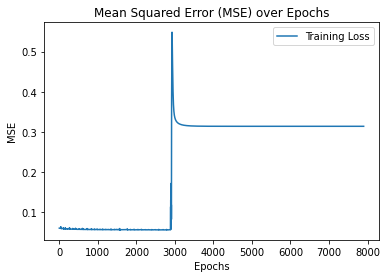

LF NN done
26/26 [==============================] - 0s 4ms/step

LF Model:
R^2: -2.4290645718026473
1/1 [==============================] - 0s 13ms/step


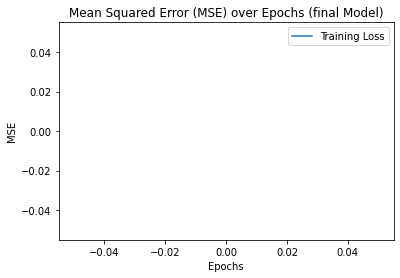

26/26 [==============================] - 0s 2ms/step
Elapsed time:  1.9013385000871494

HF Model:
Test MSE: 0.05252061417472928
Test MAE: 0.19163715365443357
Test RMSE: 0.2291737641501079
R^2: 0.5114831040871445
26/26 [==============================] - 0s 2ms/step


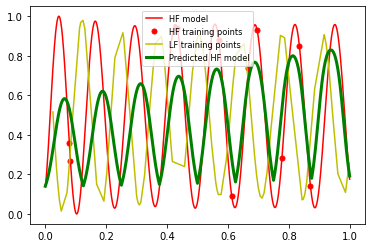

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:236: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:238: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:240: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:242: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 81  ********************
********************  # Diff: = 5  ********************


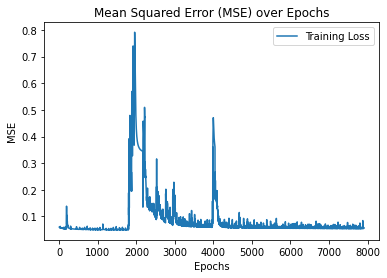

LF NN done
3/3 [==============================] - 0s 0s/step

LF Model:
R^2: 0.5732988054443774
1/1 [==============================] - 0s 34ms/step


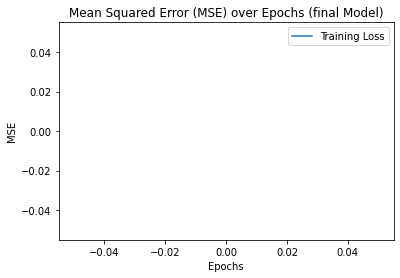

26/26 [==============================] - 0s 2ms/step
Elapsed time:  2.713170100003481

HF Model:
Test MSE: 0.0510801537662055
Test MAE: 0.185837541527457
Test RMSE: 0.2260091895614103
R^2: 0.5248814479282183
26/26 [==============================] - 0s 2ms/step


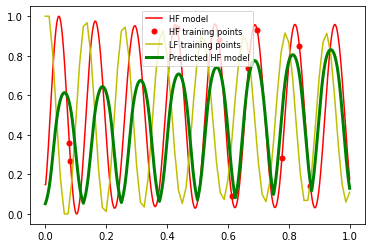

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:236: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:238: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:240: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:242: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 41  ********************
********************  # Diff: = 5  ********************


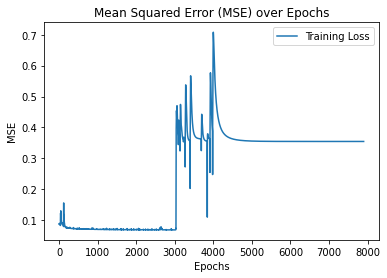

LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
R^2: -2.275422482113936
1/1 [==============================] - 0s 16ms/step


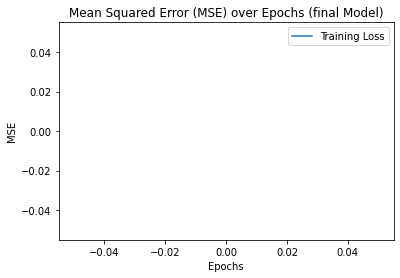

26/26 [==============================] - 0s 3ms/step
Elapsed time:  2.5995718999765813

HF Model:
Test MSE: 0.04906991984126177
Test MAE: 0.1886479535422363
Test RMSE: 0.2215173127348329
R^2: 0.5435795011117766
26/26 [==============================] - 0s 2ms/step


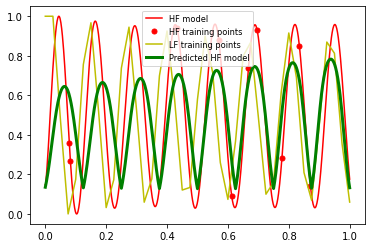

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:236: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:238: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:240: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:242: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 9  ********************
********************  # Diff: = 5  ********************


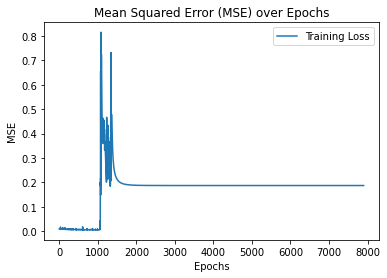

LF NN done
1/1 [==============================] - 0s 135ms/step

LF Model:
R^2: -0.7391777518897427
1/1 [==============================] - 0s 33ms/step


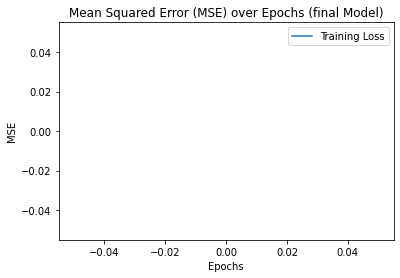

26/26 [==============================] - 0s 2ms/step
Elapsed time:  1.8937741999980062

HF Model:
Test MSE: 0.06359936499547822
Test MAE: 0.18773239232809735
Test RMSE: 0.25218914527687
R^2: 0.4084348620475763
26/26 [==============================] - 0s 1ms/step


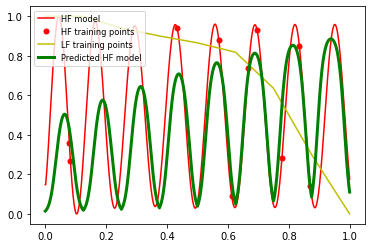

   Discretization       R2  diffusion
0             0.0  0.51148        5.0
1             5.0  0.52488        5.0
2            10.0  0.54358        5.0
3            50.0  0.40843        5.0
   Discretization      MSE  diffusion
0             0.0  0.05252        5.0
1             5.0  0.05108        5.0
2            10.0  0.04907        5.0
3            50.0  0.06360        5.0


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:236: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:238: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:240: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_11836\687041548.py:242: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

In [29]:
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        
        ### IMPORT LF DATASETs
        file_name= os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_LF_46"+"_d"+str(diffusion[d])+"_t"+str(Discretizations[m])+".mat")
        (reaction_LF_test, U_LF_test) = import_data(file_name)
        
        U_LF_test = U_LF_test[
        - 1,
        :,
        44,44
        ]
        
        reaction_LF_test=normalization(reaction_LF_test)
        U_LF_test=normalization(U_LF_test)
        
        permutation = np.random.permutation(len(reaction_LF_test))
        reaction_LF = reaction_LF_test[permutation][0:Nlf]
        U_train_LF = U_LF_test[permutation][0:Nlf]
        
        reaction_LF=np.c_[reaction_LF, np.abs(np.sin(8*np.pi*reaction_LF[:, 0]))]
        reaction_LF_test=np.c_[reaction_LF_test,np.abs(np.sin(8*np.pi*reaction_LF_test[:, 0]))]
       
        print(
        f"********************  # Nb. nodes = {reaction_LF_test.shape[0]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )

        test_mse_HF_list = []
        test_mse_LF_list = []

        test_mae_HF_list = []
        test_mae_LF_list = []
        
        test_rmse_HF_list = []
        test_rmse_LF_list = []
        
        r2_HF_list = []
        r2_LF_list = []
        
        ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        } 
        
        # reproducibilty porpuse (serve?)
        learning_rate = bestLF_params["lr"]
        optimizer_type = bestLF_params["opt"]

        # Fissa i parametri di ottimizzazione
        if optimizer_type == "Adam":
            optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        elif optimizer_type == "Nadam":
            optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        elif optimizer_type == "Adamax":
            optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        else:
            raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
        #

        
        modelLF = getModel(bestLF_params, "LF")  # ann_functions
        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        plt.plot(modelLF.history.history['loss'][100:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()

        print("LF NN done")

        ULF = modelLF.predict(reaction_LF_test)

        U_LF_list.append(ULF)
        print("\nLF Model:")
        
        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        # Mean Absolute Error (MAE)
        test_mae = np.mean(np.abs(U_LF_test - ULF[:, 0]))
        # Root Mean Squared Error (RMSE)
        test_rmse = np.sqrt(np.mean((U_LF_test - ULF[:, 0])**2))
        
        test_mse_LF_list.append(test_mse)
        test_mae_LF_list.append(test_mae)
        test_rmse_LF_list.append(test_rmse)

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")
        
        start = perf_counter()
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.concatenate(
        (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
        )  
        
        #=np.vstack(
        #    (reaction_HF_test[:, 0], reaction_test_help)
        #).transpose()  # <- TEST INPUT for the second NN: NN_HF

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_final =np.concatenate(
        (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
        )
        #=np.vstack(
        #    (reaction_HF[:, 0], reaction_train_help)
        #).transpose()  # <- TRAINING INPUT for the second NN: NN_HF

        name = "2step"
        K.clear_session()
        # best parameters obtained by HPO:

        best_params = {
            "kernel_init": "uniform",
            "l2weight": 0.0002588943618918075,
            "lr": 0.008365144388542751,
            "nodes": 6.0,
            "opt": "Adam",
        }
        
         # reproducibilty porpuse 
        learning_rate = best_params["lr"]
        optimizer_type = best_params["opt"]

        # Fissa i parametri di ottimizzazione
        if optimizer_type == "Adam":
            optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        elif optimizer_type == "Nadam":
            optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        elif optimizer_type == "Adamax":
            optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        else:
            raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
        #
        
        
        
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            verbose=0,
            validation_freq=20,
        )
        plt.plot(finalModel.history.history['loss'][50:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs (final Model)')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()
        
        UHF = finalModel.predict(reaction_test_in)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)
        print("\nHF Model:")

        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")
        
        test_mae = np.mean(np.abs(U_HF_test - UHF[:, 0]))
        test_mae_HF_list.append(test_mae)
        print(f"Test MAE: {test_mae}")
        
        test_rmse = np.sqrt(np.mean((U_HF_test - UHF[:, 0])**2))
        test_rmse_HF_list.append(test_rmse)
        print(f"Test RMSE: {test_rmse}")
        

        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")
        
        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "r-", linewidth=1.5, label="HF model"
        )
        
        order=np.argsort(reaction_final[:,0])
        plt.plot(
        reaction_final[:, 0][order],
        U_HF[order],
        "ro",
        markersize=5,
        label="HF training points",
        )
        
        order=np.argsort(reaction_LF[:,0])
        plt.plot(
        reaction_LF[order,0],
        U_train_LF[order],
        "y-",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_in),
        "g-",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()

        #r2_LF_df[[str(Discretizations[m]),diffusion[d]]] = r2_LF_list
        #r2_HF_df[[str(Discretizations[m]),diffusion[d]]] = r2_HF_list
        #mse_LF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_LF_list
        #mse_HF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_HF_list
        
        
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        r2_LF_df=r2_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        r2_HF_df=r2_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
        mse_LF_df=mse_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
        mse_HF_df=mse_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MAE': test_mae_LF_list[-1]}
        mae_LF_df=mae_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MAE': test_mae_HF_list[-1]}
        mae_HF_df=mae_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'RMSE': test_rmse_LF_list[-1]}
        rmse_LF_df=mae_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MAE': test_rmse_HF_list[-1]}
        rmse_HF_df=rmse_HF_df.append(new, ignore_index=True)
        
        if len(r2_HF_list[:-1])>0 and r2_HF_list[-1]<max(r2_HF_list[:-1]):
            save_model(finalModel,"finalModel2NN.h5")
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

## Save the output

In [31]:
os.makedirs("MF_LF_100_8000_HF_10_50_t_singleparam")

r2_HF_df.to_csv(
    "./MF_LF_100_8000_HF_10_50_t_singleparam/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_100_8000_HF_10_50_t_singleparam/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_100_8000_HF_10_50_t_singleparam/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_100_8000_HF_10_50_t_singleparam/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_100_8000_HF_10_50_t_singleparam/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_100_8000_HF_10_50_t_singleparam/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)